In [75]:
import tensorflow  as tf

In [76]:
from tensorflow import keras
from tensorflow.keras.preprocessing.image  import load_img
import numpy as np

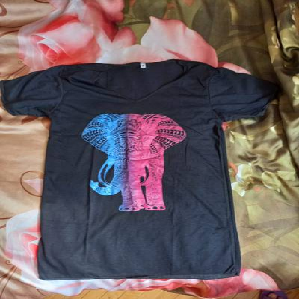

In [77]:
path = './train/t-shirt'
name = '1.jpg'
full_path = path + '/' + name
img = load_img(full_path, target_size=(299, 299))
img

In [78]:
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x7F4540129310>


In [79]:
X = np.array(img)

In [80]:
X.shape

(299, 299, 3)

In [81]:
X =  np.array([X])

##### 8.3.Pre-trained convolutional neural 
   - image dataset:https://www.image-net.org/
   - pre-trained models:https://keras.io/api/applications/

In [82]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [83]:
X = preprocess_input(X)

In [84]:
X[0]

array([[[ 0.04313731, -0.24705881, -0.372549  ],
        [ 0.082353  , -0.20784312, -0.3490196 ],
        [ 0.14509809, -0.14509803, -0.2862745 ],
        ...,
        [-0.5294118 , -0.6627451 , -0.7882353 ],
        [-0.49019605, -0.62352943, -0.7490196 ],
        [-0.4823529 , -0.6156863 , -0.7411765 ]],

       [[ 0.12941182, -0.1607843 , -0.30196077],
        [ 0.11372554, -0.17647058, -0.31764704],
        [ 0.15294123, -0.1372549 , -0.27843136],
        ...,
        [-0.47450978, -0.60784316, -0.7490196 ],
        [-0.4823529 , -0.6156863 , -0.77254903],
        [-0.5058824 , -0.64705884, -0.8039216 ]],

       [[ 0.21568632, -0.09019607, -0.2235294 ],
        [ 0.16078436, -0.12941176, -0.27058822],
        [ 0.12941182, -0.1607843 , -0.30196077],
        ...,
        [-0.47450978, -0.6       , -0.79607844],
        [-0.58431375, -0.7254902 , -0.9137255 ],
        [-0.46666664, -0.62352943, -0.8117647 ]],

       ...,

       [[ 0.00392163, -0.3333333 , -0.40392154],
        [ 0

In [85]:
model = Xception(weights="imagenet",input_shape=(299,299,3))

In [86]:
pred  = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step


In [87]:
pred

array([[5.33825769e-05, 7.50096733e-05, 5.80910928e-05, 5.65912851e-05,
        1.16855183e-04, 5.57708518e-05, 6.93736802e-05, 3.90113455e-05,
        6.13452503e-05, 9.54220086e-05, 1.02697231e-04, 9.02758766e-05,
        2.77542695e-05, 6.70777372e-05, 4.31983790e-05, 1.38039992e-04,
        8.67921262e-05, 8.47471601e-05, 8.04085939e-05, 7.75933804e-05,
        2.05366930e-04, 5.80800661e-05, 1.24909042e-04, 9.14976408e-05,
        8.57321429e-05, 9.91091365e-05, 9.66904627e-05, 1.26863612e-04,
        1.59985109e-04, 8.99398729e-05, 1.92297448e-04, 8.04217052e-05,
        1.65469872e-04, 2.20657952e-04, 1.00884106e-04, 1.74290646e-04,
        5.66265408e-05, 7.61121846e-05, 7.49078827e-05, 9.25149361e-05,
        5.08361991e-05, 2.04606287e-04, 9.57090888e-05, 8.34312814e-05,
        1.90807710e-04, 1.17837641e-04, 1.53396846e-04, 7.68366881e-05,
        1.59897856e-04, 1.99831891e-04, 2.16862929e-04, 6.74132025e-05,
        3.08618241e-04, 3.58690624e-04, 1.33536203e-04, 1.472008

In [88]:
decode_predictions(pred)

[[('n03595614', 'jersey', 0.87694037),
  ('n03710637', 'maillot', 0.009399748),
  ('n04370456', 'sweatshirt', 0.0067942035),
  ('n03877472', 'pajama', 0.004636027),
  ('n04525038', 'velvet', 0.0033033718)]]

In [89]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator as IM

In [90]:
train_gen =  IM(preprocessing_function=preprocess_input)

In [91]:
train_ds = train_gen.flow_from_directory('./train',target_size=(150,150),batch_size=32)

Found 3068 images belonging to 10 classes.


In [92]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [93]:
X,y = next(train_ds)

In [94]:
X

array([[[[-0.7019608 , -0.8509804 , -0.8980392 ],
         [-0.69411767, -0.8901961 , -0.8666667 ],
         [-0.7411765 , -0.9137255 , -0.8901961 ],
         ...,
         [-0.44313723, -0.5372549 , -0.52156866],
         [-0.75686276, -0.827451  , -0.8666667 ],
         [-0.6627451 , -0.7176471 , -0.79607844]],

        [[-0.7019608 , -0.8509804 , -0.8980392 ],
         [-0.69411767, -0.8901961 , -0.8666667 ],
         [-0.7411765 , -0.9137255 , -0.8901961 ],
         ...,
         [-0.78039217, -0.827451  , -0.827451  ],
         [-0.60784316, -0.6627451 , -0.70980394],
         [-0.41176468, -0.46666664, -0.54509807]],

        [[-0.69411767, -0.85882354, -0.8980392 ],
         [-0.69411767, -0.8901961 , -0.8666667 ],
         [-0.7490196 , -0.90588236, -0.8901961 ],
         ...,
         [-0.70980394, -0.75686276, -0.75686276],
         [-0.3098039 , -0.44313723, -0.4980392 ],
         [-0.38039213, -0.56078434, -0.60784316]],

        ...,

        [[ 0.5137255 , -0.47450978, -0

In [95]:
y[:9]

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)

In [96]:
val_gen =  IM(preprocessing_function=preprocess_input)
val_ds = val_gen.flow_from_directory('./validation',target_size=(150,150),batch_size=32,shuffle=False)

Found 341 images belonging to 10 classes.


In [97]:
val_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}